## Project: Feature Engineering on Healthcare Patient Records
This project explores a healthcare dataset to perform data cleaning, feature engineering, and model building for heart disease prediction.


In [11]:


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    roc_curve,
    auc
)

# Step 2: Load dataset
df = pd.read_csv('heart_disease_uci.csv')
df.head()

,id,age,sex,dataset,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,num
0,1,63,Male,Cleveland,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,2,67,Male,Cleveland,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,2
2,3,67,Male,Cleveland,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,4,37,Male,Cleveland,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,5,41,Female,Cleveland,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [12]:
print("Shape:", df.shape)
df.info()
df.describe().T


Shape: (920, 16)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 920 entries, 0 to 919
Data columns (total 16 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        920 non-null    int64  
 1   age       920 non-null    int64  
 2   sex       920 non-null    object 
 3   dataset   920 non-null    object 
 4   cp        920 non-null    object 
 5   trestbps  861 non-null    float64
 6   chol      890 non-null    float64
 7   fbs       830 non-null    object 
 8   restecg   918 non-null    object 
 9   thalch    865 non-null    float64
 10  exang     865 non-null    object 
 11  oldpeak   858 non-null    float64
 12  slope     611 non-null    object 
 13  ca        309 non-null    float64
 14  thal      434 non-null    object 
 15  num       920 non-null    int64  
dtypes: float64(5), int64(3), object(8)
memory usage: 115.1+ KB


,count,mean,std,min,25%,50%,75%,max
id,920.0,460.500000,265.725422,1.0,230.75,460.5,690.25,920.0
age,920.0,53.510870,9.424685,28.0,47.00,54.0,60.00,77.0
trestbps,861.0,132.132404,19.066070,0.0,120.00,130.0,140.00,200.0
chol,890.0,199.130337,110.780810,0.0,175.00,223.0,268.00,603.0
thalch,865.0,137.545665,25.926276,60.0,120.00,140.0,157.00,202.0
oldpeak,858.0,0.878788,1.091226,-2.6,0.00,0.5,1.50,6.2
ca,309.0,0.676375,0.935653,0.0,0.00,0.0,1.00,3.0
num,920.0,0.995652,1.142693,0.0,0.00,1.0,2.00,4.0


In [13]:
# 1. Check missing values in each column
df.isnull().sum()

id            0
age           0
sex           0
dataset       0
cp            0
trestbps     59
chol         30
fbs          90
restecg       2
thalch       55
exang        55
oldpeak      62
slope       309
ca          611
thal        486
num           0
dtype: int64

In [14]:
df['num'].value_counts()

num
0    411
1    265
2    109
3    107
4     28
Name: count, dtype: int64

In [15]:
import numpy as np

# 1️⃣ Create binary target: 0 = no disease, 1 = disease present
df['target'] = (df['num'] > 0).astype(int)

# 2️⃣ Drop columns that are not needed for modelling
df.drop(columns=['id', 'dataset', 'num'], inplace=True)

# Check the new columns
df.head()

,age,sex,cp,trestbps,chol,fbs,restecg,thalch,exang,oldpeak,slope,ca,thal,target
0,63,Male,typical angina,145.0,233.0,True,lv hypertrophy,150.0,False,2.3,downsloping,0.0,fixed defect,0
1,67,Male,asymptomatic,160.0,286.0,False,lv hypertrophy,108.0,True,1.5,flat,3.0,normal,1
2,67,Male,asymptomatic,120.0,229.0,False,lv hypertrophy,129.0,True,2.6,flat,2.0,reversable defect,1
3,37,Male,non-anginal,130.0,250.0,False,normal,187.0,False,3.5,downsloping,0.0,normal,0
4,41,Female,atypical angina,130.0,204.0,False,lv hypertrophy,172.0,False,1.4,upsloping,0.0,normal,0


In [16]:
cols_with_invalid_zeros = ['trestbps', 'chol', 'thalch']

df[cols_with_invalid_zeros] = df[cols_with_invalid_zeros].replace(0, np.nan)

# Check how many missing values we have now
df[cols_with_invalid_zeros].isnull().sum()

trestbps     60
chol        202
thalch       55
dtype: int64

In [17]:
from sklearn.preprocessing import LabelEncoder

# Fill numeric missing values with median
for col in df.select_dtypes(include=['float64', 'int64']).columns:
    df[col] = df[col].fillna(df[col].median())

# Fill categorical missing values with mode
for col in df.select_dtypes(include='object').columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# Encode categorical features
labelencoder = LabelEncoder()
for col in df.select_dtypes(include='object').columns:
    df[col] = labelencoder.fit_transform(df[col])

# Check missing values
df.isnull().sum().sum()

C:\Users\Amreen\AppData\Local\Temp\ipykernel_15436\3852772079.py:9: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].fillna(df[col].mode()[0])


0

C:\Users\Amreen\AppData\Local\Temp\ipykernel_15436\3647087018.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='target', data=df, palette='Set2')


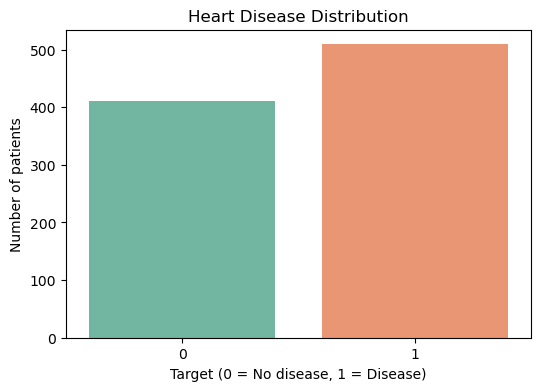

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,4))
sns.countplot(x='target', data=df, palette='Set2')
plt.title('Heart Disease Distribution')
plt.xlabel('Target (0 = No disease, 1 = Disease)')
plt.ylabel('Number of patients')
plt.show()

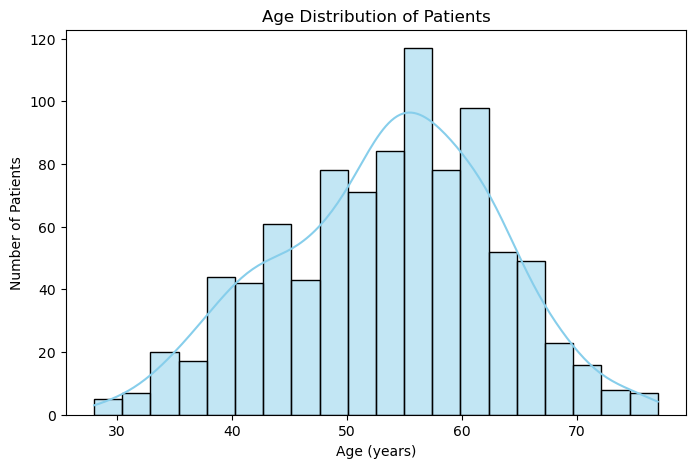

In [19]:
plt.figure(figsize=(8,5))
sns.histplot(df['age'], bins=20, kde=True, color='skyblue')
plt.title('Age Distribution of Patients')
plt.xlabel('Age (years)')
plt.ylabel('Number of Patients')
plt.show()

C:\Users\Amreen\AppData\Local\Temp\ipykernel_15436\3150057272.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='age', data=df, palette='coolwarm')


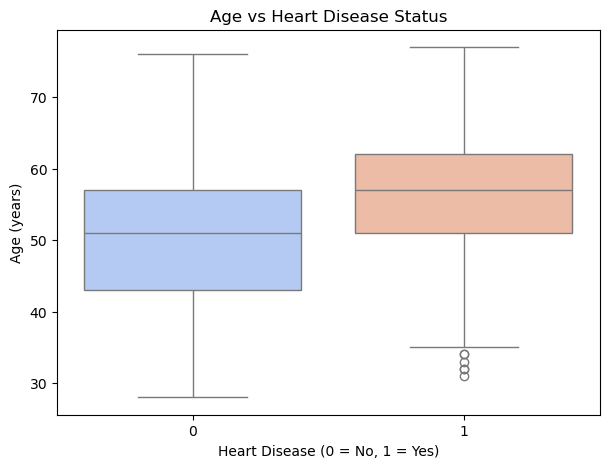

In [20]:
plt.figure(figsize=(7,5))
sns.boxplot(x='target', y='age', data=df, palette='coolwarm')
plt.title('Age vs Heart Disease Status')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Age (years)')
plt.show()

C:\Users\Amreen\AppData\Local\Temp\ipykernel_15436\771233071.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='target', y='chol', data=df, palette='mako')


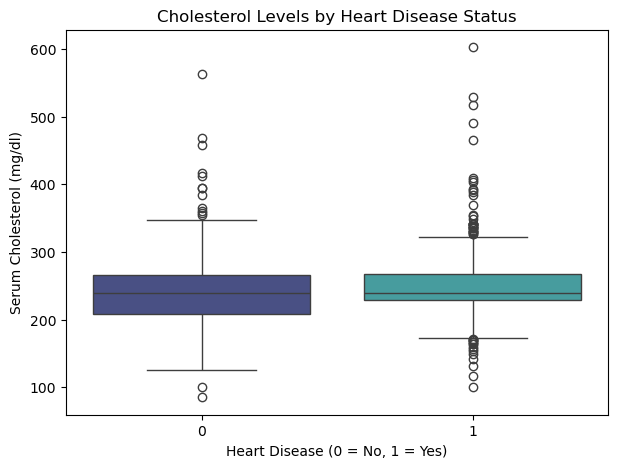

In [21]:
plt.figure(figsize=(7,5))
sns.boxplot(x='target', y='chol', data=df, palette='mako')
plt.title('Cholesterol Levels by Heart Disease Status')
plt.xlabel('Heart Disease (0 = No, 1 = Yes)')
plt.ylabel('Serum Cholesterol (mg/dl)')
plt.show()

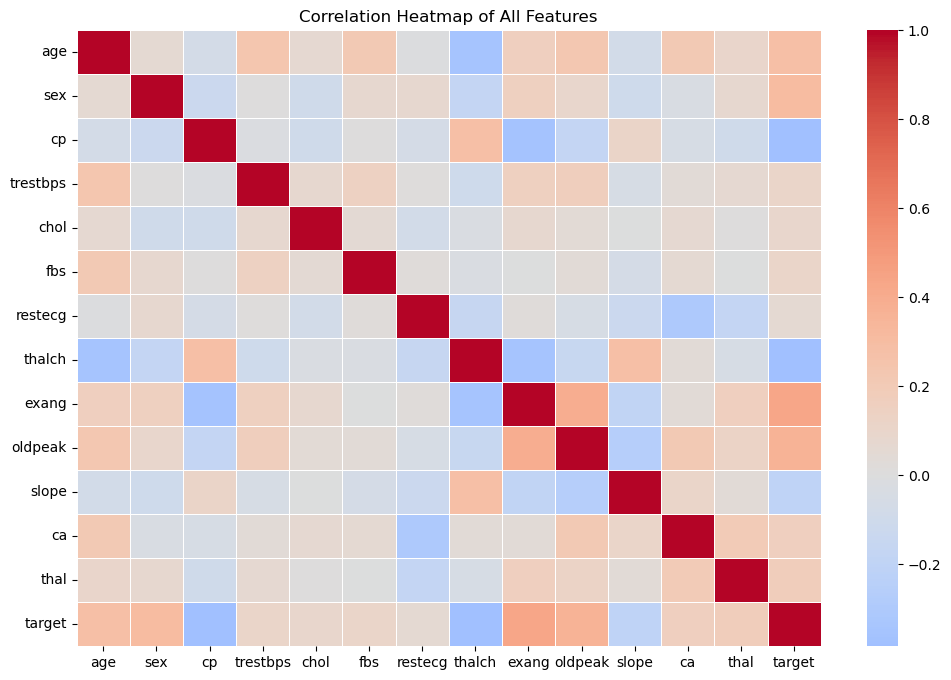

In [22]:
plt.figure(figsize=(12,8))
corr = df.corr()

sns.heatmap(
    corr,
    cmap='coolwarm',
    annot=False,
    center=0,
    linewidths=0.5
)

plt.title('Correlation Heatmap of All Features')
plt.show()

In [23]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 1️⃣  Separate features and target
X = df.drop(columns=['target'])
y = df['target']

# 2️⃣  Split data (80 % train, 20 % test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 3️⃣  Scale features for better model performance
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Train shape:", X_train.shape, "  Test shape:", X_test.shape)

Train shape: (736, 13)   Test shape: (184, 13)


In [24]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# 1️⃣  Train model
log_reg = LogisticRegression(max_iter=1000)
log_reg.fit(X_train_scaled, y_train)

# 2️⃣  Predictions
y_pred = log_reg.predict(X_test_scaled)

# 3️⃣  Evaluation
acc = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)
print("Accuracy :", round(acc,3))
print("\nConfusion Matrix :\n", cm)
print("\nClassification Report :\n", classification_report(y_test, y_pred))

Accuracy : 0.793

Confusion Matrix :
 [[60 22]
 [16 86]]

Classification Report :
               precision    recall  f1-score   support

           0       0.79      0.73      0.76        82
           1       0.80      0.84      0.82       102

    accuracy                           0.79       184
   macro avg       0.79      0.79      0.79       184
weighted avg       0.79      0.79      0.79       184



In [32]:
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestClassifier

# Base model
rf = RandomForestClassifier(random_state=42)

# Parameter grid to search
param_grid = {
    'n_estimators': [100, 200, 500],
    'max_depth': [None, 5, 10, 20],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4]
}
# Grid search with 5-fold cross-validation
grid_search = GridSearchCV(
    estimator=rf,
    param_grid=param_grid,
    cv=5,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train, y_train)

print("Best parameters:", grid_search.best_params_)
print("Best CV accuracy:", round(grid_search.best_score_, 3))

Fitting 5 folds for each of 108 candidates, totalling 540 fits
Best parameters: {'max_depth': 10, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 200}
Best CV accuracy: 0.81


In [33]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Best model from grid search
best_rf = grid_search.best_estimator_

# Predictions on test set
y_pred_best_rf = best_rf.predict(X_test)

# Evaluation
acc_best_rf = accuracy_score(y_test, y_pred_best_rf)
cm_best_rf = confusion_matrix(y_test, y_pred_best_rf)

print("Test Accuracy (Best RF):", round(acc_best_rf, 3))
print("\nConfusion Matrix:\n", cm_best_rf)
print("\nClassification Report:\n", classification_report(y_test, y_pred_best_rf))

Test Accuracy (Best RF): 0.783

Confusion Matrix:
 [[59 23]
 [17 85]]

Classification Report:
               precision    recall  f1-score   support

           0       0.78      0.72      0.75        82
           1       0.79      0.83      0.81       102

    accuracy                           0.78       184
   macro avg       0.78      0.78      0.78       184
weighted avg       0.78      0.78      0.78       184



### Conclusion
The Random Forest model achieved an accuracy of 78%. The dataset was successfully cleaned and transformed, demonstrating the importance of feature engineering in improving predictive performance.
